CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [5]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [7]:
# 모델 초기화
net = myCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)
train_losses = []
test_losses = []
test_accuracies = []

# 손실 함수 및 옵티마이저 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

모델 학습 ✅

In [8]:
# 학습 함수 정의
def train(model, train_loader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_losses.append(running_loss / len(train_loader))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {100.*correct/total:.2f}%")



모델 평가 ✅

In [9]:
# 평가 함수 정의
# 평가 함수 정의 (테스트 데이터에 대해 10번 반복)
def test(model, test_loader, device, epochs=10):
    model.eval()
    for epoch in range(epochs):
        correct = 0
        total = 0
        test_loss = 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_losses.append(test_loss / len(test_loader))
        test_accuracies.append(100. * correct / total)
        print(f"Test Epoch {epoch+1}/{epochs}, Test Accuracy: {100.*correct/total:.2f}%")



10회 반복 시행 ✅

In [10]:
# TODO
train(net, train_loader, optimizer, criterion, device, epochs=10)

Epoch 1/10, Loss: 0.7891, Accuracy: 76.87%
Epoch 2/10, Loss: 0.1270, Accuracy: 96.12%
Epoch 3/10, Loss: 0.0847, Accuracy: 97.38%
Epoch 4/10, Loss: 0.0652, Accuracy: 98.03%
Epoch 5/10, Loss: 0.0539, Accuracy: 98.30%
Epoch 6/10, Loss: 0.0468, Accuracy: 98.51%
Epoch 7/10, Loss: 0.0406, Accuracy: 98.78%
Epoch 8/10, Loss: 0.0361, Accuracy: 98.88%
Epoch 9/10, Loss: 0.0321, Accuracy: 99.00%
Epoch 10/10, Loss: 0.0308, Accuracy: 99.03%


In [11]:
# 학습 완료 후 10번 테스트 실행
test(net, test_loader, device, epochs=10)

Test Epoch 1/10, Test Accuracy: 98.92%
Test Epoch 2/10, Test Accuracy: 98.92%
Test Epoch 3/10, Test Accuracy: 98.92%
Test Epoch 4/10, Test Accuracy: 98.92%
Test Epoch 5/10, Test Accuracy: 98.92%
Test Epoch 6/10, Test Accuracy: 98.92%
Test Epoch 7/10, Test Accuracy: 98.92%
Test Epoch 8/10, Test Accuracy: 98.92%
Test Epoch 9/10, Test Accuracy: 98.92%
Test Epoch 10/10, Test Accuracy: 98.92%


결과 시각화

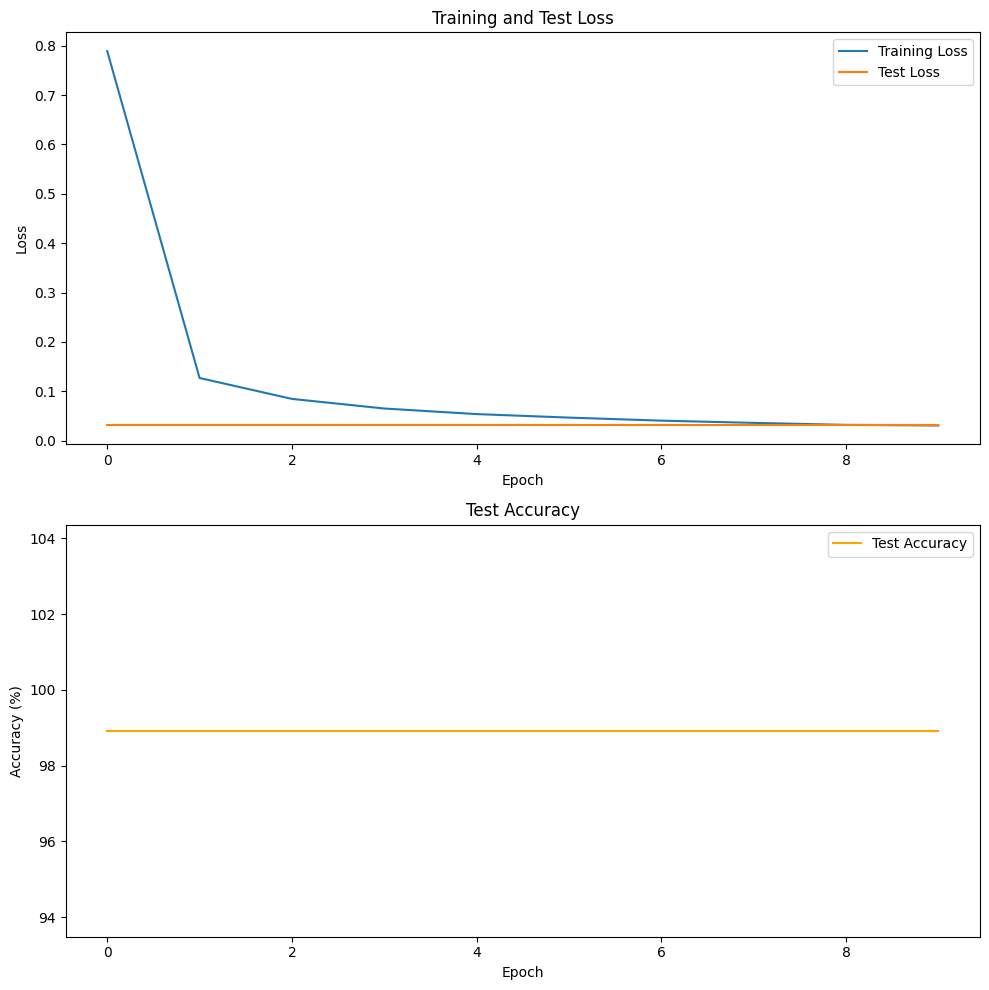

In [12]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()